# Hypothesis Text Quality

This notebook quantifies the text quality of retained natural-language hypotheses. It computes specificity and conciseness metrics, summarizes these metrics by experiment and task outcome, saves CSV outputs, and displays the comparison figures used in the report.


## 1. Setup

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as DisplayImage, display


def resolve_project_root() -> Path:
    """Walk upward from cwd until we find a directory that contains final_outputs/."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "final_outputs").is_dir():
            return candidate
        legacy = candidate / "sample" / "final_outputs"
        if legacy.is_dir():
            return candidate / "sample"
    raise FileNotFoundError(
        "Could not locate experiment outputs. Expected a `final_outputs` directory "
        "(at the project root or under `sample/`). Unzip `final_outputs.zip` if needed, "
        "and run the notebook with the working directory inside the repo (e.g. open "
        "the project folder in Cursor/Jupyter)."
    )


ROOT = resolve_project_root()
print(f"Project root: {ROOT}")


Project root: /Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation


## 2. Helper functions

This section defines the data-loading, metric-computation, CSV-writing, and plotting functions used in the analysis below.


In [3]:
import csv
import re
from collections import defaultdict
from pathlib import Path
from statistics import mean, median
from typing import Any

import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ROOT is defined in the setup cell.
FINAL_OUTPUTS = ROOT / "final_outputs"
OUTPUT_DIR = ROOT / "analysis_outputs"

EXPERIMENTS = [
    ("2_hypo_program", "Hypothesis + Program"),
    ("3_hint_hypo_program", "Hint + Hypothesis + Program"),
    ("4_good_hypo_program", "High Quality Hypothesis + Program"),
]

EXPERIMENT_COLORS = ["#4C78A8", "#F58518", "#54A24B"]
OUTCOME_COLORS = {"Unsolved": "#9A9A9A", "Solved": "#4C78A8"}

COLOR_TERMS = {
    "black",
    "blue",
    "red",
    "green",
    "yellow",
    "gray",
    "grey",
    "orange",
    "cyan",
    "teal",
    "purple",
    "magenta",
    "brown",
    "white",
    "nonzero",
    "non-zero",
}

SPATIAL_TERMS = {
    "row",
    "rows",
    "column",
    "columns",
    "left",
    "right",
    "top",
    "bottom",
    "upper",
    "lower",
    "horizontal",
    "vertically",
    "vertical",
    "diagonal",
    "anti-diagonal",
    "between",
    "adjacent",
    "center",
    "middle",
    "edge",
    "border",
    "corner",
    "inside",
    "outside",
    "nearest",
    "outermost",
    "leftmost",
    "rightmost",
    "topmost",
    "bottommost",
}

ACTION_TERMS = {
    "move",
    "moves",
    "moving",
    "shift",
    "shifts",
    "translate",
    "fill",
    "fills",
    "draw",
    "draws",
    "connect",
    "connects",
    "extend",
    "extends",
    "expand",
    "expands",
    "crop",
    "crops",
    "extract",
    "select",
    "selects",
    "copy",
    "copies",
    "repeat",
    "repeats",
    "tile",
    "tiles",
    "recolor",
    "recolored",
    "replace",
    "replaces",
    "remove",
    "removes",
    "erase",
    "mirror",
    "rotate",
    "preserve",
    "preserves",
    "keep",
    "keeps",
    "leave",
    "leaves",
    "identify",
    "identifies",
    "locate",
    "find",
    "count",
    "compare",
    "map",
    "mark",
    "group",
    "merge",
    "sort",
}

OBJECT_TERMS = {
    "cell",
    "cells",
    "object",
    "objects",
    "component",
    "components",
    "shape",
    "shapes",
    "block",
    "blocks",
    "pattern",
    "patterns",
    "line",
    "lines",
    "grid",
    "grids",
    "region",
    "regions",
    "marker",
    "markers",
    "anchor",
    "anchors",
    "motif",
    "template",
    "background",
}

CONDITION_TERMS = {
    "if",
    "when",
    "otherwise",
    "unless",
    "only",
    "except",
    "while",
    "every",
    "each",
    "all",
    "same",
    "different",
    "unchanged",
    "preserving",
    "preserve",
    "out",
    "bounds",
    "edge",
    "border",
}


def read_csv(path: Path) -> list[dict[str, str]]:
    with path.open("r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))


def write_csv(path: Path, rows: list[dict[str, Any]], fieldnames: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)


def bool_value(value: Any) -> bool:
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def tokens(text: str) -> list[str]:
    return re.findall(r"[a-zA-Z]+(?:-[a-zA-Z]+)?|\d+", text.lower())


def sentence_count(text: str) -> int:
    parts = [part.strip() for part in re.split(r"[.!?]+", text) if part.strip()]
    return max(1, len(parts))


def count_terms(words: list[str], term_set: set[str]) -> int:
    return sum(1 for word in words if word in term_set)


def hypothesis_metrics(text: str) -> dict[str, Any]:
    words = tokens(text)
    word_count = len(words)
    sentences = sentence_count(text)
    numeric_count = sum(1 for word in words if word.isdigit())
    color_count = count_terms(words, COLOR_TERMS) + numeric_count
    spatial_count = count_terms(words, SPATIAL_TERMS)
    action_count = count_terms(words, ACTION_TERMS)
    object_count = count_terms(words, OBJECT_TERMS)
    condition_count = count_terms(words, CONDITION_TERMS)

    specificity_score = (
        color_count + spatial_count + action_count + object_count + condition_count
    )
    specificity_per_100_words = (
        specificity_score / word_count * 100 if word_count else 0.0
    )
    avg_sentence_length = word_count / sentences if sentences else 0.0

    return {
        "word_count": word_count,
        "sentence_count": sentences,
        "avg_sentence_length": avg_sentence_length,
        "numeric_count": numeric_count,
        "color_terms": color_count,
        "spatial_terms": spatial_count,
        "action_terms": action_count,
        "object_terms": object_count,
        "condition_terms": condition_count,
        "specificity_score": specificity_score,
        "specificity_per_100_words": specificity_per_100_words,
    }


def collect_task_rows() -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []

    for experiment_order, (folder, name) in enumerate(EXPERIMENTS):
        raw_rows = read_csv(FINAL_OUTPUTS / folder / "results.csv")
        grouped: dict[str, list[dict[str, str]]] = defaultdict(list)
        for row in raw_rows:
            grouped[row["task_id"]].append(row)

        for task_id, task_rows in grouped.items():
            first = task_rows[0]
            correct_count = sum(bool_value(row.get("correct")) for row in task_rows)
            total_examples = len(task_rows)
            text = first.get("best_hypothesis", "") or ""
            metric_values = hypothesis_metrics(text)
            rows.append(
                {
                    "experiment_order": experiment_order,
                    "experiment_folder": folder,
                    "experiment_name": name,
                    "task_id": task_id,
                    "difficulty": first.get("difficulty", ""),
                    "test_examples": total_examples,
                    "correct_test_examples": correct_count,
                    "example_accuracy": correct_count / total_examples
                    if total_examples
                    else 0.0,
                    "task_correct": correct_count == total_examples
                    and total_examples > 0,
                    "hypothesis": text,
                    **metric_values,
                }
            )

    return sorted(rows, key=lambda r: (r["experiment_order"], r["task_id"]))


def summarize(rows: list[dict[str, Any]]) -> list[dict[str, Any]]:
    metric_names = [
        "specificity_score",
        "specificity_per_100_words",
        "word_count",
        "sentence_count",
        "avg_sentence_length",
    ]
    grouped: dict[str, list[dict[str, Any]]] = defaultdict(list)
    for row in rows:
        grouped[row["experiment_folder"]].append(row)

    summaries = []
    for experiment_order, (folder, name) in enumerate(EXPERIMENTS):
        group = grouped[folder]
        item: dict[str, Any] = {
            "experiment_order": experiment_order,
            "experiment_folder": folder,
            "experiment_name": name,
            "task_count": len(group),
            "solved_tasks": sum(int(row["task_correct"]) for row in group),
            "task_accuracy": sum(int(row["task_correct"]) for row in group)
            / len(group)
            if group
            else 0.0,
        }
        for metric in metric_names:
            values = [float(row[metric]) for row in group]
            item[f"{metric}_mean"] = mean(values) if values else 0.0
            item[f"{metric}_median"] = median(values) if values else 0.0
        summaries.append(item)

    return summaries


def add_bar_labels(ax: plt.Axes, bars: Any, fmt: str = "{:.1f}") -> None:
    labels = [fmt.format(bar.get_height()) for bar in bars]
    ax.bar_label(bars, labels=labels, fontsize=8, padding=2)


def set_zoomed_y_axis(ax: plt.Axes, values: list[float]) -> None:
    value_min = min(values)
    value_max = max(values)
    span = max(value_max - value_min, 1.0)
    lower_padding = span * 0.35
    upper_padding = span * 0.45
    ax.set_ylim(value_min - lower_padding, value_max + upper_padding)

    # Mark that the y-axis is truncated rather than starting from zero.
    break_kwargs = dict(
        transform=ax.transAxes,
        color="black",
        clip_on=False,
        linewidth=1.2,
    )
    ax.plot((-0.015, 0.015), (-0.02, 0.02), **break_kwargs)
    ax.plot((0.025, 0.055), (-0.02, 0.02), **break_kwargs)


def plot_metric_means(summary: list[dict[str, Any]], output_path: Path) -> None:
    labels = [row["experiment_name"] for row in summary]
    x = list(range(len(labels)))
    panels = [
        (
            "specificity_per_100_words_mean",
            "Specificity",
            "Mean score per 100 words",
            None,
            "{:.1f}",
        ),
        (
            "word_count_mean",
            "Conciseness",
            "Mean conciseness (words; lower is better)",
            None,
            "{:.0f}",
        ),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes_flat = axes.flatten()

    for index, (metric, title, ylabel, ymax, fmt) in enumerate(panels):
        ax = axes_flat[index]
        values = [row[metric] for row in summary]
        bars = ax.bar(x, values, color=EXPERIMENT_COLORS)
        add_bar_labels(ax, bars, fmt)
        ax.set_title(title)
        ax.set_ylabel(f"{ylabel} (zoomed)")
        ax.set_xticks([])
        if ymax is not None:
            ax.set_ylim(0, ymax)
        else:
            set_zoomed_y_axis(ax, values)
        ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle("Retained Hypothesis Text Metrics by Experiment", fontsize=16, y=0.98)
    legend_handles = [
        Patch(facecolor=color, edgecolor="none", label=label)
        for color, label in zip(EXPERIMENT_COLORS, labels)
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.91),
        ncol=3,
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.88))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=200)
    plt.close(fig)


def plot_success_boxplots(rows: list[dict[str, Any]], output_path: Path) -> None:
    panels = [
        ("specificity_per_100_words", "Specificity / 100 Words"),
        ("word_count", "Conciseness\n(words; lower is better)"),
    ]

    solved = [row for row in rows if row["task_correct"]]
    unsolved = [row for row in rows if not row["task_correct"]]

    fig, axes = plt.subplots(1, len(panels), figsize=(10, 5))
    for ax, (metric, title) in zip(axes, panels):
        data = [
            [row[metric] for row in unsolved],
            [row[metric] for row in solved],
        ]
        bp = ax.boxplot(
            data,
            tick_labels=[
                f"Unsolved\n(n={len(unsolved)})",
                f"Solved\n(n={len(solved)})",
            ],
            patch_artist=True,
            showfliers=False,
        )
        for patch, color in zip(bp["boxes"], ["#BAB0AC", "#76B7B2"]):
            patch.set_facecolor(color)
        ax.set_title(title)
        ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)

    fig.suptitle("Retained Hypothesis Metrics by Final Task Outcome", fontsize=16)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=200)
    plt.close(fig)


def print_summary(summary: list[dict[str, Any]]) -> None:
    print("Hypothesis text metric summary:")
    for row in summary:
        print(
            f"- {row['experiment_folder']}: "
            f"specificity={row['specificity_per_100_words_mean']:.1f}/100w, "
            f"words={row['word_count_mean']:.1f}"
        )


def main() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    rows = collect_task_rows()
    summary = summarize(rows)

    metric_fields = [
        "experiment_order",
        "experiment_folder",
        "experiment_name",
        "task_id",
        "difficulty",
        "test_examples",
        "correct_test_examples",
        "example_accuracy",
        "task_correct",
        "specificity_score",
        "specificity_per_100_words",
        "color_terms",
        "spatial_terms",
        "action_terms",
        "object_terms",
        "condition_terms",
        "word_count",
        "sentence_count",
        "avg_sentence_length",
        "hypothesis",
    ]

    summary_fields = [
        "experiment_order",
        "experiment_folder",
        "experiment_name",
        "task_count",
        "solved_tasks",
        "task_accuracy",
    ]
    for metric in [
        "specificity_score",
        "specificity_per_100_words",
        "word_count",
        "sentence_count",
        "avg_sentence_length",
    ]:
        summary_fields.extend([f"{metric}_mean", f"{metric}_median"])

    write_csv(OUTPUT_DIR / "hypothesis_text_metrics.csv", rows, metric_fields)
    write_csv(
        OUTPUT_DIR / "hypothesis_text_metric_summary.csv", summary, summary_fields
    )
    plot_metric_means(
        summary, OUTPUT_DIR / "hypothesis_quality_metric_means.png"
    )
    plot_success_boxplots(
        rows, OUTPUT_DIR / "hypothesis_quality_by_success.png"
    )

    print_summary(summary)
    print(f"\nWrote outputs to: {OUTPUT_DIR}")


## 3. Metric definition and keyword inventory

Specificity is the number of matched color, numeric, spatial, action, object, and condition terms per 100 words. Conciseness is the word count, where lower is more concise.

In [4]:
keyword_counts = pd.DataFrame([
    {"category": "color + numeric", "keyword_count": len(COLOR_TERMS), "note": "numeric tokens are counted separately"},
    {"category": "spatial", "keyword_count": len(SPATIAL_TERMS), "note": ""},
    {"category": "action", "keyword_count": len(ACTION_TERMS), "note": ""},
    {"category": "object", "keyword_count": len(OBJECT_TERMS), "note": ""},
    {"category": "condition", "keyword_count": len(CONDITION_TERMS), "note": ""},
])
display(keyword_counts)

,category,keyword_count,note
0,color + numeric,16,numeric tokens are counted separately
1,spatial,30,
2,action,53,
3,object,25,
4,condition,19,


## 3. Load selected hypotheses and compute per-task metrics

In [5]:
rows = collect_task_rows()
metrics_df = pd.DataFrame(rows)
print(metrics_df.shape)
display(metrics_df[["experiment_name", "task_id", "difficulty", "task_correct", "specificity_per_100_words", "word_count", "hypothesis"]].head())

(300, 21)


,experiment_name,task_id,difficulty,task_correct,specificity_per_100_words,word_count,hypothesis
0,Hypothesis + Program,025d127b,Easy,False,34.020619,97,Describing the input grid: The input contains ...
1,Hypothesis + Program,0a938d79,Easy,False,20.930233,86,Describing the input grid: The input is a most...
2,Hypothesis + Program,0b148d64,Easy,False,35.964912,114,Describing the input grid: The input consists ...
3,Hypothesis + Program,0d3d703e,Easy,True,41.176471,102,Describing the input grid: The input is a 3x3 ...
4,Hypothesis + Program,0dfd9992,Medium,True,36.470588,85,Describing the input grid: The input is made o...


## 5. Summarize metrics by experiment and outcome

In [6]:
summary = summarize(rows)
summary_df = pd.DataFrame(summary)
display(summary_df[["experiment_name", "task_count", "solved_tasks", "task_accuracy", "specificity_per_100_words_mean", "specificity_per_100_words_median", "word_count_mean", "word_count_median"]])

outcome_summary = metrics_df.groupby("task_correct").agg(tasks=("task_id", "count"), median_specificity=("specificity_per_100_words", "median"), median_conciseness_words=("word_count", "median")).rename(index={False: "Unsolved", True: "Solved"})
display(outcome_summary)

,experiment_name,task_count,solved_tasks,task_accuracy,specificity_per_100_words_mean,specificity_per_100_words_median,word_count_mean,word_count_median
0,Hypothesis + Program,100,25,0.25,28.458639,28.177984,99.90,97.0
1,Hint + Hypothesis + Program,100,38,0.38,26.831002,26.533166,103.52,102.0
2,High Quality Hypothesis + Program,100,82,0.82,30.591510,31.047266,97.30,96.0


,tasks,median_specificity,median_conciseness_words
task_correct,,,
Unsolved,155,26.88172,105.0
Solved,145,30.30303,93.0


## 6. Save CSV outputs

In [7]:
metric_fields = ["experiment_order", "experiment_folder", "experiment_name", "task_id", "difficulty", "test_examples", "correct_test_examples", "example_accuracy", "task_correct", "specificity_score", "specificity_per_100_words", "color_terms", "spatial_terms", "action_terms", "object_terms", "condition_terms", "word_count", "sentence_count", "avg_sentence_length", "hypothesis"]
summary_fields = ["experiment_order", "experiment_folder", "experiment_name", "task_count", "solved_tasks", "task_accuracy"]
for metric in ["specificity_score", "specificity_per_100_words", "word_count", "sentence_count", "avg_sentence_length"]:
    summary_fields.extend([f"{metric}_mean", f"{metric}_median"])
write_csv(OUTPUT_DIR / "hypothesis_text_metrics.csv", rows, metric_fields)
write_csv(OUTPUT_DIR / "hypothesis_text_metric_summary.csv", summary, summary_fields)
print(OUTPUT_DIR / "hypothesis_text_metrics.csv")
print(OUTPUT_DIR / "hypothesis_text_metric_summary.csv")

/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/hypothesis_text_metrics.csv
/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/hypothesis_text_metric_summary.csv


## 7. Plot and display charts

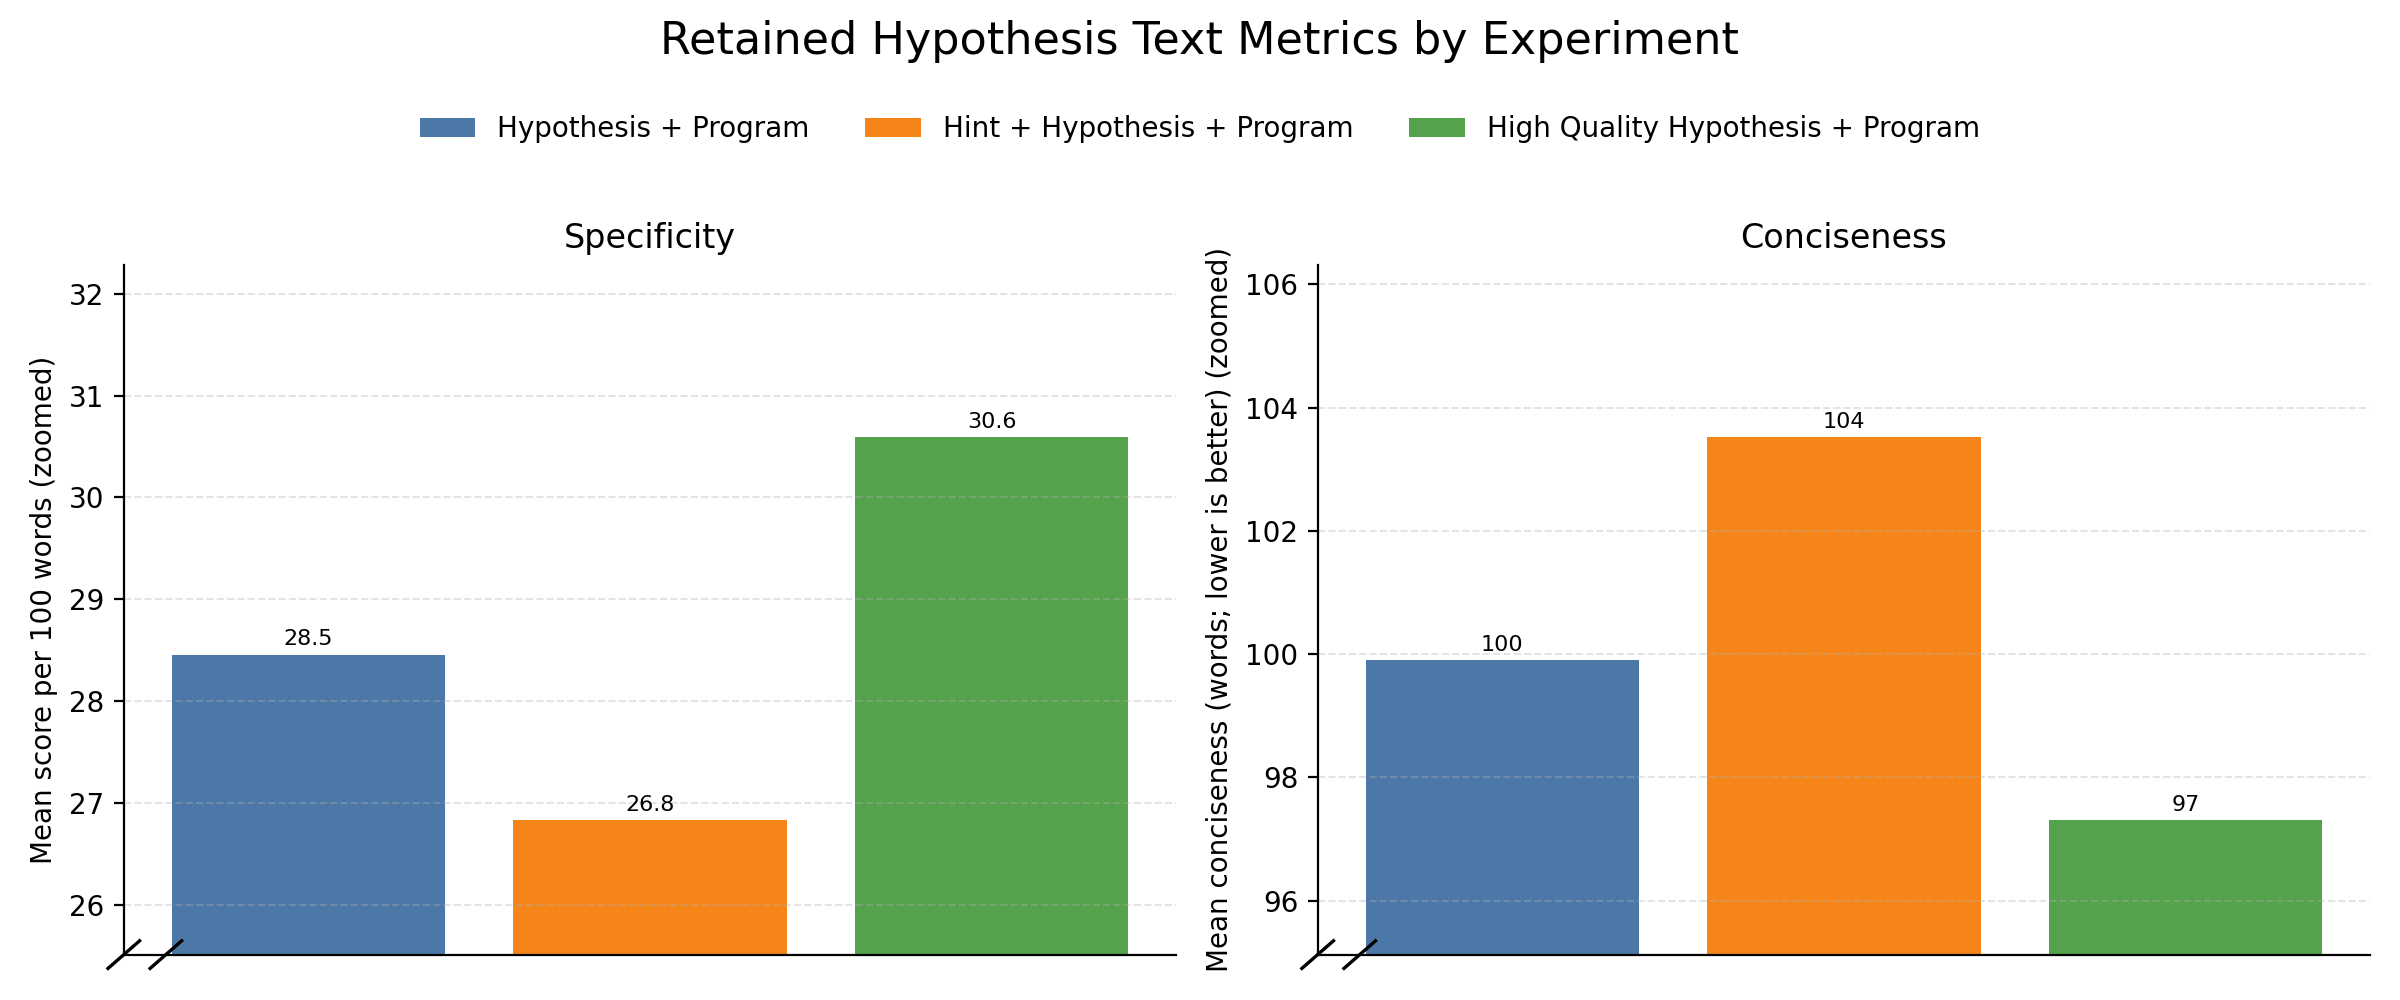

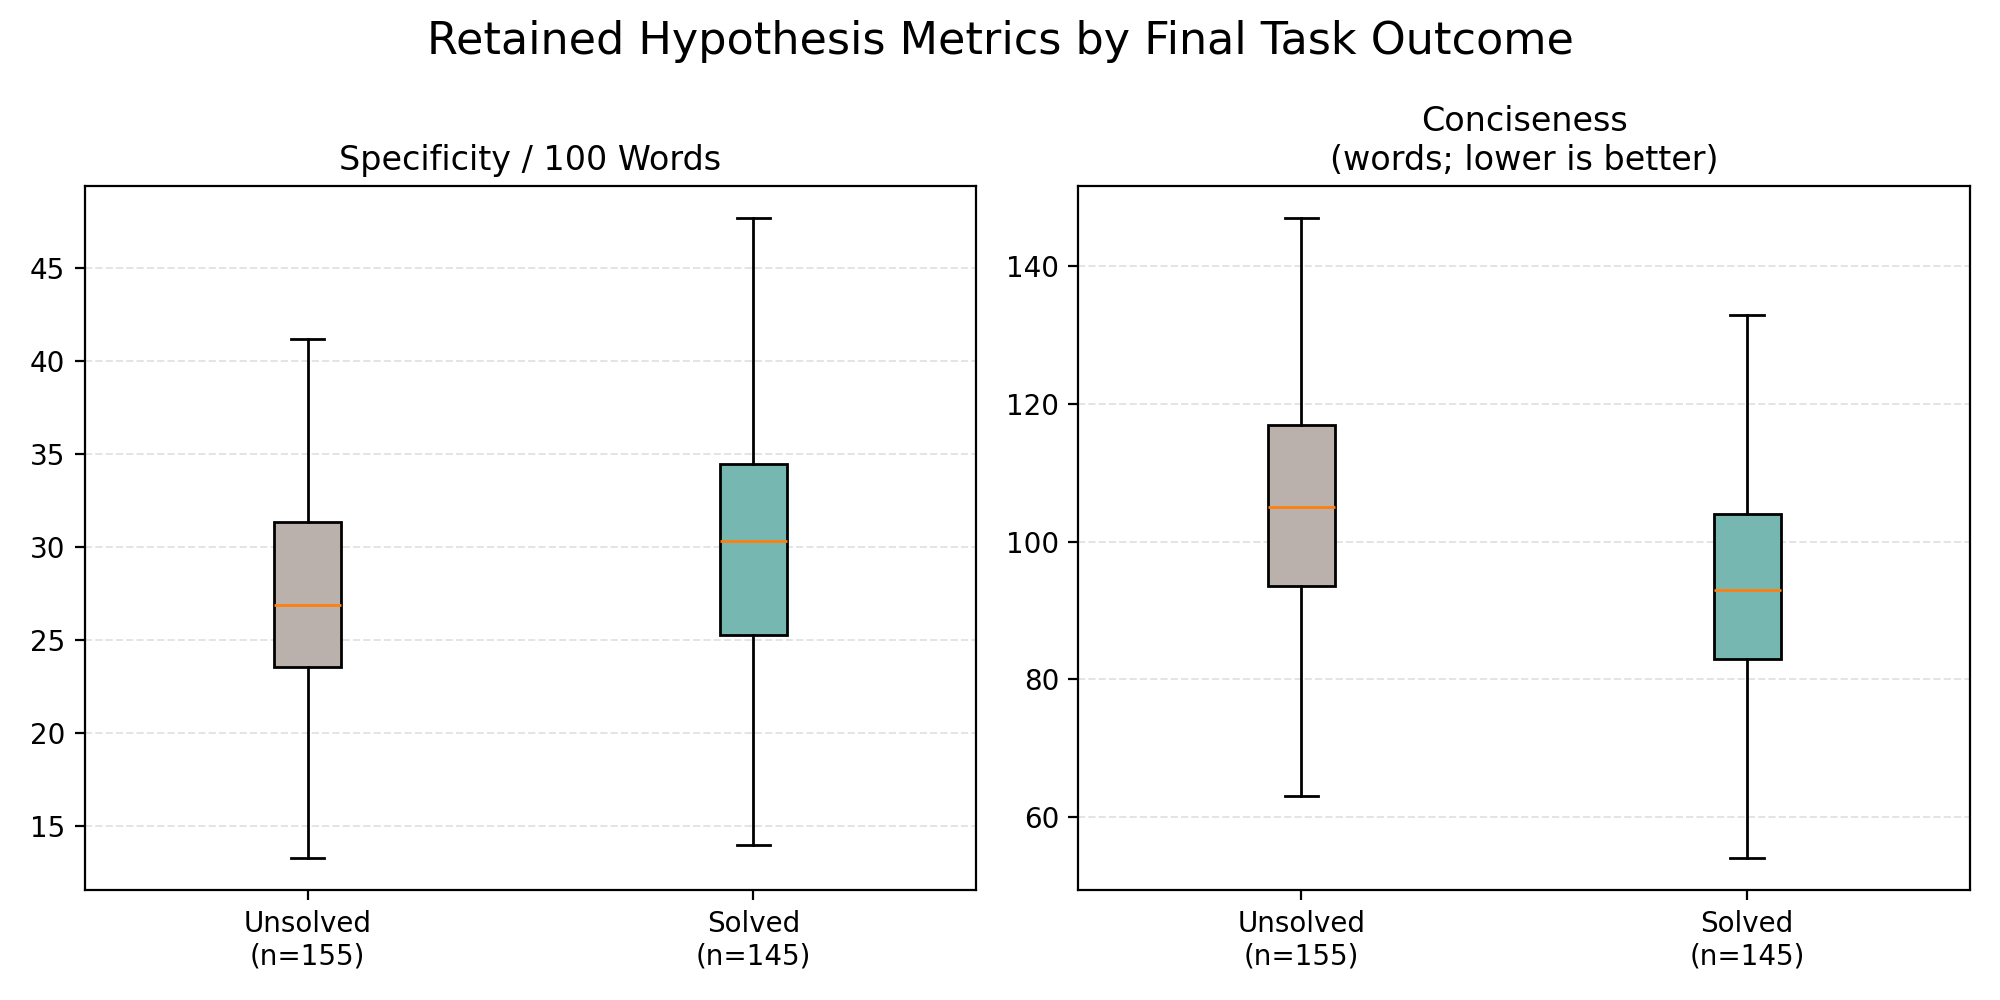

In [8]:
means_fig = OUTPUT_DIR / "hypothesis_quality_metric_means.png"
success_fig = OUTPUT_DIR / "hypothesis_quality_by_success.png"
plot_metric_means(summary, means_fig)
plot_success_boxplots(rows, success_fig)
display(DisplayImage(filename=str(means_fig)))
display(DisplayImage(filename=str(success_fig)))